# Tokyo Airbnb Market Analysis — EDA & Dashboard

This notebook explores Airbnb listings in Tokyo (2023) and prepares 
data for an interactive business dashboard.

**Dataset:** 11,177 listings | Source: Inside Airbnb (via Kaggle)  
**Key questions:**
- What are the price patterns across Tokyo neighbourhoods?
- Which room types dominate the market?
- Where are the highest-rated listings concentrated?

## 1. Setup & Data Loading

In [9]:
import pandas as pd
import numpy as np

listings = pd.read_csv('data/listings.csv')
reviews = pd.read_csv('data/reviews.csv')
neighbourhoods = pd.read_csv('data/neighbourhoods.csv')

print(f"Listings: {listings.shape}")
print(f"Reviews: {reviews.shape}")
print(f"Neighbourhoods: {neighbourhoods.shape}")

print(f"\nListings columns:")
print(listings.columns.tolist())

Listings: (11177, 75)
Reviews: (407712, 6)
Neighbourhoods: (62, 2)

Listings columns:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', '

In [11]:
# Select key columns for dashboard
key_cols = ['id', 'name', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed',
            'latitude', 'longitude', 'room_type', 'property_type',
            'accommodates', 'bedrooms', 'beds', 'price',
            'minimum_nights', 'number_of_reviews', 'review_scores_rating',
            'host_is_superhost', 'instant_bookable', 'availability_365']

df = listings[key_cols].copy()

# Clean price column (remove $ and commas)
df['price'] = df['price'].str.replace('$', '', regex=False)\
                          .str.replace(',', '', regex=False)\
                          .astype(float)

print("=== Key Stats ===")
print(f"Total listings: {len(df):,}")
print(f"Neighbourhoods: {df['neighbourhood_cleansed'].nunique()}")
print(f"Neighbourhood groups: {df['neighbourhood_group_cleansed'].nunique()}")
print(f"\nRoom types:")
print(df['room_type'].value_counts())
print(f"\nPrice stats:")
print(df['price'].describe().round(2))
print(f"\nMissing values:")
print(df.isnull().sum())

=== Key Stats ===
Total listings: 11,177
Neighbourhoods: 46
Neighbourhood groups: 0

Room types:
room_type
Entire home/apt    8085
Private room       2574
Hotel room          274
Shared room         244
Name: count, dtype: int64

Price stats:
count      11177.00
mean       21800.17
std        48449.80
min            0.00
25%         9029.00
50%        14429.00
75%        23929.00
max      1306500.00
Name: price, dtype: float64

Missing values:
id                                  0
name                                0
neighbourhood_cleansed              0
neighbourhood_group_cleansed    11177
latitude                            0
longitude                           0
room_type                           0
property_type                       0
accommodates                        0
bedrooms                         1940
beds                              461
price                               0
minimum_nights                      0
number_of_reviews                   0
review_scores_rating

### Observations

- **11,177 listings** across 46 neighbourhoods
- **72% are entire homes/apartments** — Tokyo Airbnb market 
  is dominated by full property rentals
- **Median price: ¥14,429/night** — reasonable for Tokyo
- **Max price: ¥1,306,500** — extreme outlier, likely luxury property
- `neighbourhood_group_cleansed` is entirely empty — will be dropped

## 2. Data Cleaning

In [15]:
# Clean data
df = df.drop('neighbourhood_group_cleansed', axis=1)

# Remove price outliers (top 1%)
q99 = df['price'].quantile(0.99)
df = df[df['price'] > 0]
df = df[df['price'] <= q99]

# Fill missing values
df['bedrooms'] = df['bedrooms'].fillna(0)
df['beds'] = df['beds'].fillna(0)
df['review_scores_rating'] = df['review_scores_rating'].fillna(
    df['review_scores_rating'].median())
df['host_is_superhost'] = df['host_is_superhost'].fillna('f')

print(f"Clean dataset: {len(df):,} listings")
print(f"Price range: ¥{df['price'].min():,.0f} — ¥{df['price'].max():,.0f}")
print(f"Median price: ¥{df['price'].median():,.0f}")

# Save for dashboard
df.to_csv('data/listings_clean.csv', index=False)
print("Saved: data/listings_clean.csv")

Clean dataset: 11,067 listings
Price range: ¥1,450 — ¥99,999
Median price: ¥14,293
Saved: data/listings_clean.csv


### Cleaning Results

- Removed 110 listings with zero or extreme prices (top 1%)
- Dropped empty `neighbourhood_group_cleansed` column
- Filled missing bedrooms/beds with 0
- Filled missing ratings with median value
- **Final dataset: 11,067 listings | Price range: ¥1,450 — ¥99,999**

## 3. Exploratory Data Analysis

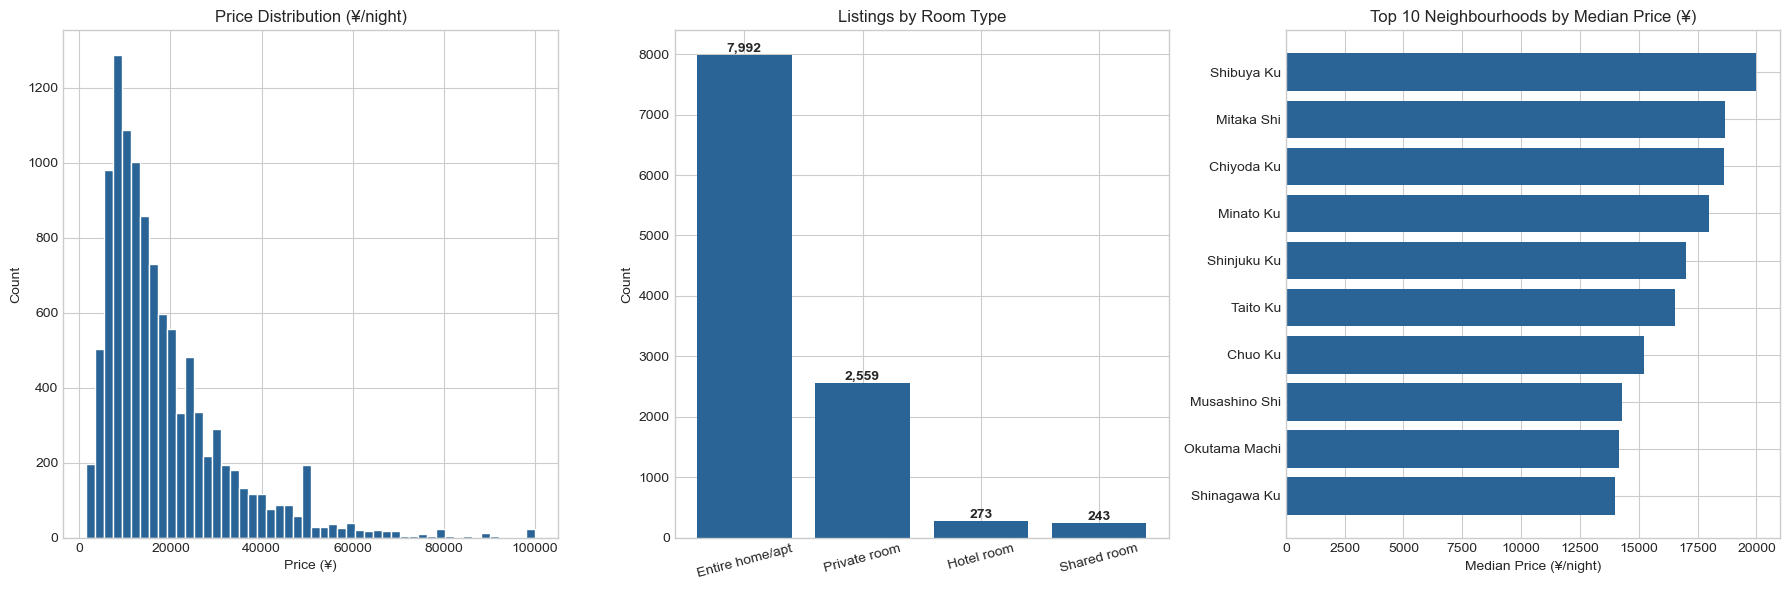

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('visuals', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Plot 1: Price distribution ---
axes[0].hist(df['price'], bins=50, color='#2a6496', edgecolor='white')
axes[0].set_title('Price Distribution (¥/night)')
axes[0].set_xlabel('Price (¥)')
axes[0].set_ylabel('Count')

# --- Plot 2: Room types ---
room_counts = df['room_type'].value_counts()
axes[1].bar(room_counts.index, room_counts.values, color='#2a6496')
axes[1].set_title('Listings by Room Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(room_counts.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# --- Plot 3: Top 10 neighbourhoods by median price ---
top_neigh = (df.groupby('neighbourhood_cleansed')['price']
               .median()
               .sort_values(ascending=False)
               .head(10))
axes[2].barh(top_neigh.index[::-1], top_neigh.values[::-1], color='#2a6496')
axes[2].set_title('Top 10 Neighbourhoods by Median Price (¥)')
axes[2].set_xlabel('Median Price (¥/night)')

plt.tight_layout()
plt.savefig('visuals/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations

- **Price distribution** is right-skewed — most listings are 
  priced between ¥5,000–¥30,000/night
- **Entire home/apt dominates** (72%) — Tokyo guests prefer 
  full property rentals over shared spaces
- **Shibuya, Minato, Chiyoda** are the most expensive neighbourhoods — 
  prime central Tokyo locations command premium prices
- **Okutama** appears in top 10 despite being a rural mountain area — 
  likely luxury nature retreats with high nightly rates

## 4. Dashboard

Based on this EDA, we built an interactive Dash dashboard (`app.py`) 
that allows users to:
- Filter listings by room type, neighbourhood, and price range
- See key KPIs updating in real time
- Explore price patterns across Tokyo neighbourhoods
- Visualize listing locations on an interactive map

**To run the dashboard:**
```bash
python app.py
```
Then open http://127.0.0.1:8050 in your browser.

## 5. Conclusions

### Key Findings

1. **Tokyo Airbnb market is dominated by entire homes (72%)** — 
   guests prefer full privacy over shared spaces
2. **Median price ¥14,293/night** — with significant variation 
   across neighbourhoods
3. **Shibuya, Minato, Chiyoda** are the most expensive neighbourhoods — 
   central Tokyo commands a clear premium
4. **Average rating 4.67/5** — Tokyo hosts maintain very high 
   quality standards
5. **Price distribution is right-skewed** — most listings are 
   affordable but luxury outliers exist

### Limitations & Next Steps
- Data from 2023 — prices may have changed significantly 
  post-COVID tourism recovery
- Reviews analysis could reveal seasonal patterns
- Adding calendar data would show availability trends